In [2]:
import torch

In [3]:
from torch import nn

In [6]:
from d2l import torch as d2l

In [8]:
def corr2d(x,k):
    h,w = k.shape
    y = torch.zeros((x.shape[0] - h+1, x.shape[1] - w+1))
    for i in range(y.shape[0]):
        for j in range(y.shape[1]):
            y[i,j] = (x[i:i+h, j:j+w] * k).sum()
    return y

In [9]:
x = torch.tensor([[0.0, 1.0, 2.0],[3.0, 4.0, 5.0],[6.0, 7.0, 8.0]])
k = torch.tensor([[0.0, 1.0],[2.0, 3.0]])
corr2d(x,k)

tensor([[19., 25.],
        [37., 43.]])

In [2]:
import pandas as pd

df = pd.read_csv('train.csv') # 读取数据

df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True) # 打乱数据

split_idx = int(len(df_shuffled) * 0.8) # 计算分割点

train_df = df_shuffled[:split_idx] # 分割数据
test_df = df_shuffled[split_idx:]

train_df.to_csv('train.csv', index=False) # 保存
test_df.to_csv('test.csv', index=False)

print(f"训练集大小: {len(train_df)}")
print(f"测试集大小: {len(test_df)}")

训练集大小: 80000
测试集大小: 20000


In [3]:
print(df.head)

<bound method NDFrame.head of           id                                  heartbeat_signals  label
0          0  0.9912297987616655,0.9435330436439665,0.764677...    0.0
1          1  0.9714822034884503,0.9289687459588268,0.572932...    0.0
2          2  1.0,0.9591487564065292,0.7013782792997189,0.23...    2.0
3          3  0.9757952826275774,0.9340884687738161,0.659636...    0.0
4          4  0.0,0.055816398940721094,0.26129357194994196,0...    2.0
...      ...                                                ...    ...
99995  99995  1.0,0.677705342021188,0.22239242747868546,0.25...    0.0
99996  99996  0.9268571578157265,0.9063471198026871,0.636993...    2.0
99997  99997  0.9258351628306013,0.5873839035878395,0.633226...    3.0
99998  99998  1.0,0.9947621698382489,0.8297017704865509,0.45...    2.0
99999  99999  0.9259994004527861,0.916476635326053,0.4042900...    0.0

[100000 rows x 3 columns]>


In [5]:
type(df.iloc[1])

pandas.core.series.Series

In [9]:
df.iloc[1,1]

'0.9714822034884503,0.9289687459588268,0.5729328050711678,0.1784566262750076,0.1229615224365985,0.13236021729815928,0.09439236984499814,0.08957535516351411,0.030480606866741047,0.04049936195430977,0.02039178866617264,0.027965007816101565,0.03549867995241705,0.015320799491921583,0.045482770405584606,0.03549867995241705,0.03549867995241705,0.025445016021896714,0.030480606866741047,0.030480606866741047,0.030480606866741047,0.030480606866741047,0.025445016681959063,0.02039178866617264,0.015320799491921583,0.04049936195430977,0.025445016021896714,0.03549867995241705,0.06524602377453673,0.08957535516351411,0.099193354503267,0.14169808852070362,0.14169808852070362,0.14402314068245697,0.1463444518106101,0.1784566262750076,0.1920031630840051,0.1920031630840051,0.20542368372531994,0.2231256795470371,0.2275174563894053,0.21872051112824814,0.23189588627264138,0.20986959655861195,0.20319558825083509,0.1964905619662614,0.16478169390091,0.15559252550973682,0.15097589898583877,0.1463444518106101,0.164

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [20]:
df.iloc[1:5]

,id,heartbeat_signals,label
1,1,"0.9714822034884503,0.9289687459588268,0.572932...",0.0
2,2,"1.0,0.9591487564065292,0.7013782792997189,0.23...",2.0
3,3,"0.9757952826275774,0.9340884687738161,0.659636...",0.0
4,4,"0.0,0.055816398940721094,0.26129357194994196,0...",2.0


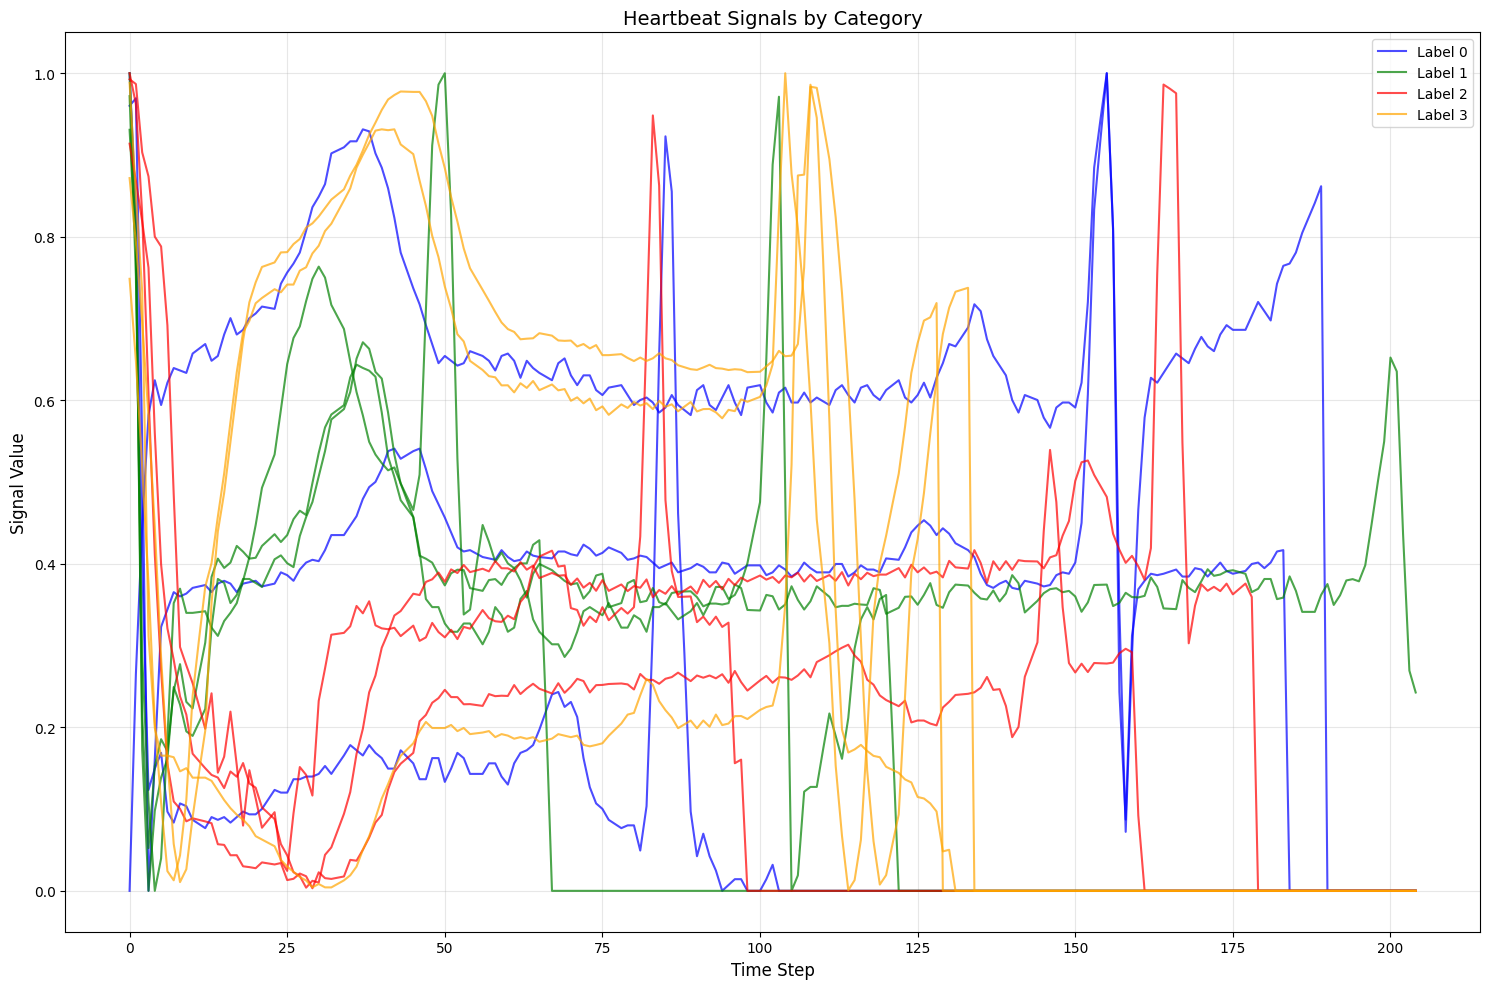

In [21]:
def parse_signals(signal_str):
    return [float(x) for x in signal_str.split(',')]

df['signals'] = df['heartbeat_signals'].apply(parse_signals)

# 为每个类别随机选择几个样本
plt.figure(figsize=(15, 10))
colors = {0: 'blue', 1: 'green', 2: 'red', 3: 'orange'}

for label in [0, 1, 2, 3]:
    # 获取该类别的数据
    label_data = df[df['label'] == label]
    
    # 随机选择3个样本
    samples = label_data.sample(min(3, len(label_data)), random_state=42)
    
    for idx, row in samples.iterrows():
        signals = row['signals']
        plt.plot(signals, color=colors[label], alpha=0.7, 
                label=f'Label {label}' if idx == samples.index[0] else "")

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Signal Value', fontsize=12)
plt.title('Heartbeat Signals by Category', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

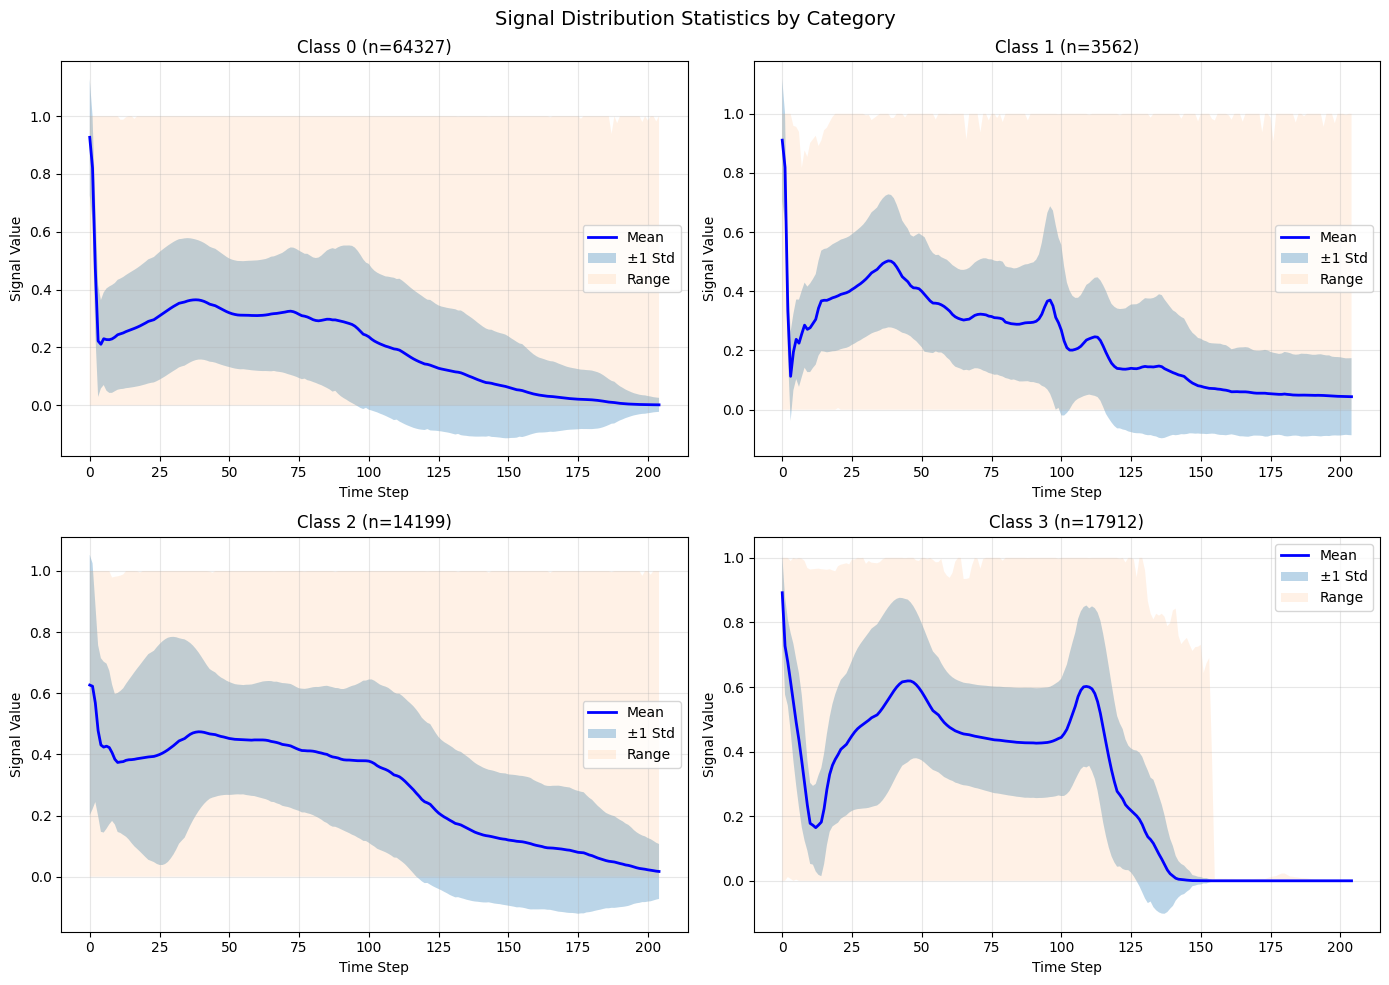

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, label in enumerate([0, 1, 2, 3]):
    label_data = df[df['label'] == label]
    signals_matrix = np.array(label_data['signals'].tolist())
    
    # 统计每个时间步的分布
    mean_signal = signals_matrix.mean(axis=0)
    std_signal = signals_matrix.std(axis=0)
    min_signal = signals_matrix.min(axis=0)
    max_signal = signals_matrix.max(axis=0)
    
    x = range(len(mean_signal))
    
    axes[i].plot(x, mean_signal, 'b-', linewidth=2, label='Mean')
    axes[i].fill_between(x, mean_signal - std_signal, mean_signal + std_signal, 
                         alpha=0.3, label='±1 Std')
    axes[i].fill_between(x, min_signal, max_signal, alpha=0.1, label='Range')
    axes[i].set_title(f'Class {label} (n={len(label_data)})', fontsize=12)
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('Signal Value')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Signal Distribution Statistics by Category', fontsize=14)
plt.tight_layout()
plt.show()

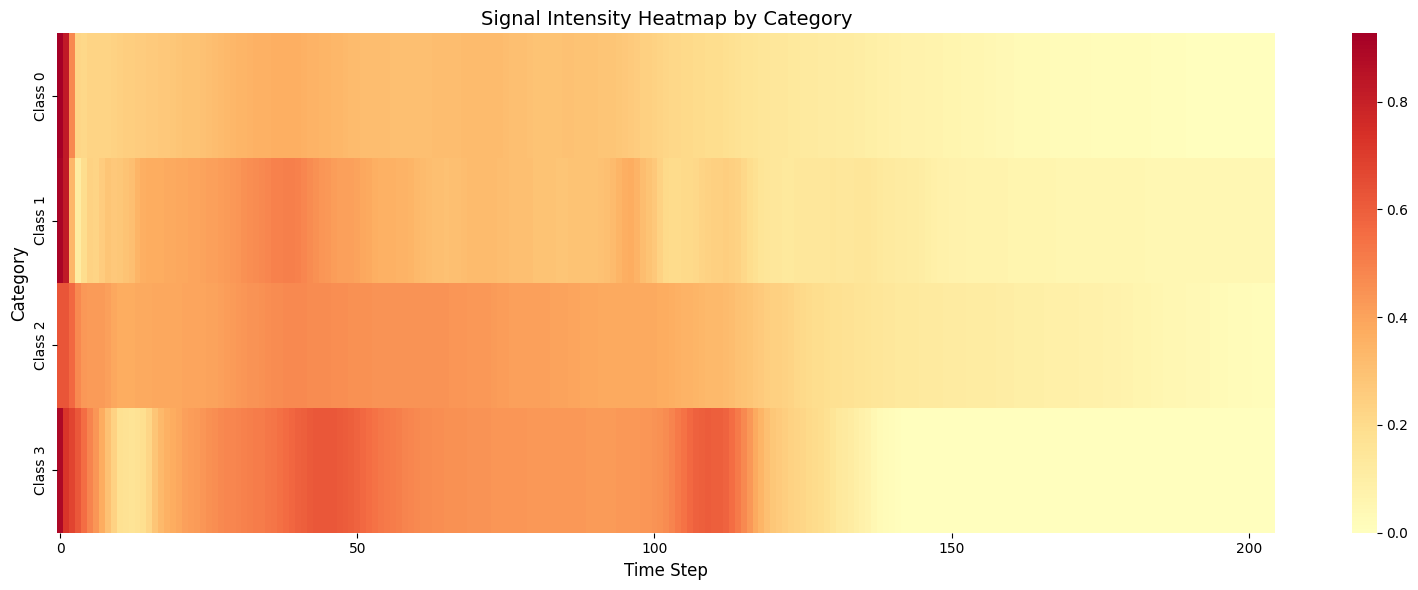

In [28]:
class_means = {}
for label in [0, 1, 2, 3]:
    label_data = df[df['label'] == label]
    signals_matrix = np.array(label_data['signals'].tolist())
    class_means[label] = signals_matrix.mean(axis=0)

# 创建热力图数据
heatmap_data = np.array([class_means[0], class_means[1], class_means[2], class_means[3]])

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='RdYlBu_r', center=0, 
            xticklabels=50, yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.title('Signal Intensity Heatmap by Category', fontsize=14)
plt.tight_layout()
plt.show()

使用设备: cuda
GPU型号: NVIDIA GeForce RTX 4090
GPU显存: 6.44 GB

加载数据...
训练集大小: 80000
测试集大小: 20000
序列长度: 205
训练集形状: (80000, 205)
测试集形状: (20000, 205)

训练集类别分布:
  Class 0: 51450 (64.3%)
  Class 1: 2813 (3.5%)
  Class 2: 11370 (14.2%)
  Class 3: 14367 (18.0%)

测试集类别分布:
  Class 0: 12877 (64.4%)
  Class 1: 749 (3.7%)
  Class 2: 2829 (14.1%)
  Class 3: 3545 (17.7%)

训练批次数: 625
测试批次数: 157

模型参数量:
  总参数: 989,509
  可训练参数: 989,509

开始训练
  ★ 保存最佳模型 (Epoch 1, Val Acc: 95.45%)
Epoch [  1/80] LR: 0.001000 | Train Loss: 0.3562, Train Acc: 89.16% | Val Loss: 0.1514, Val Acc: 95.45%
  ★ 保存最佳模型 (Epoch 2, Val Acc: 97.03%)
  ★ 保存最佳模型 (Epoch 3, Val Acc: 97.56%)
  ★ 保存最佳模型 (Epoch 4, Val Acc: 97.58%)
  ★ 保存最佳模型 (Epoch 5, Val Acc: 98.26%)
Epoch [  5/80] LR: 0.001000 | Train Loss: 0.0771, Train Acc: 97.75% | Val Loss: 0.0558, Val Acc: 98.26%
  ★ 保存最佳模型 (Epoch 8, Val Acc: 98.36%)
  ★ 保存最佳模型 (Epoch 10, Val Acc: 98.70%)
Epoch [ 10/80] LR: 0.001000 | Train Loss: 0.0505, Train Acc: 98.47% | Val Loss: 0.0462, Val Acc: 98.7

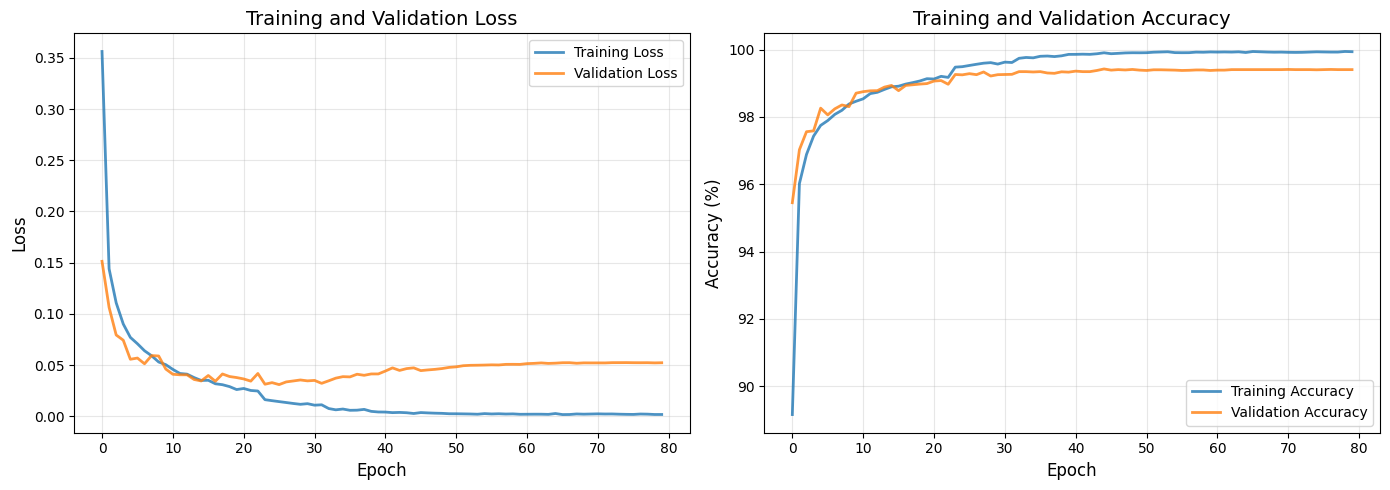


训练曲线已保存: training_history.png

加载最佳模型 (Epoch 45, Val Acc: 99.42%)

测试集准确率: 99.42%

分类报告:
                  precision    recall  f1-score   support

Class 0 (Normal)       1.00      1.00      1.00     12877
         Class 1       0.96      0.94      0.95       749
         Class 2       0.99      0.99      0.99      2829
         Class 3       1.00      1.00      1.00      3545

        accuracy                           0.99     20000
       macro avg       0.99      0.98      0.98     20000
    weighted avg       0.99      0.99      0.99     20000



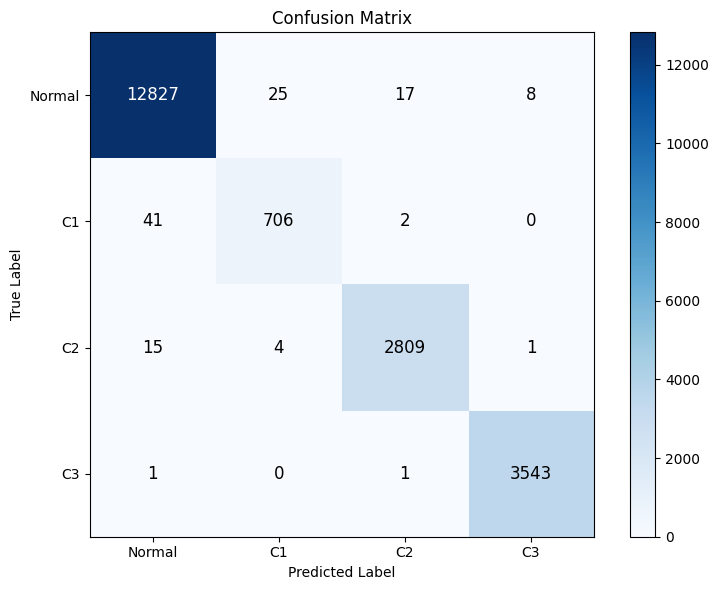

混淆矩阵已保存: confusion_matrix.png

预测示例 (使用测试集前5个样本):
样本 1: 预测=2, 真实=2 ✓
  概率分布: N:0.000, C1:0.000, C2:1.000, C3:0.000
样本 2: 预测=0, 真实=0 ✓
  概率分布: N:1.000, C1:0.000, C2:0.000, C3:0.000
样本 3: 预测=2, 真实=2 ✓
  概率分布: N:0.454, C1:0.000, C2:0.545, C3:0.001
样本 4: 预测=0, 真实=0 ✓
  概率分布: N:1.000, C1:0.000, C2:0.000, C3:0.000
样本 5: 预测=0, 真实=0 ✓
  概率分布: N:1.000, C1:0.000, C2:0.000, C3:0.000

训练历史已保存: training_history.csv
评估结果已保存: evaluation_results.txt

训练完成！生成的文件:
  1. best_cnn_lstm_model.pth - 最佳模型权重
  2. training_history.png - 训练曲线图
  3. training_history.csv - 训练历史数据
  4. confusion_matrix.png - 混淆矩阵图
  5. evaluation_results.txt - 评估结果


In [29]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ==================== 1. 设置随机种子和设备 ====================
def set_seed(seed=42):
    """设置随机种子保证可复现"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")
if torch.cuda.is_available():
    print(f"GPU型号: {torch.cuda.get_device_name(0)}")
    print(f"GPU显存: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ==================== 2. 数据加载 ====================
def load_data(train_path='train.csv', test_path='test.csv'):
    """加载已分割的CSV数据"""
    print("\n加载数据...")
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    print(f"训练集大小: {len(train_df)}")
    print(f"测试集大小: {len(test_df)}")
    
    # 解析心跳信号
    def parse_signals(signal_str):
        return [float(x) for x in str(signal_str).split(',')]
    
    # 转换数据
    X_train = np.array([parse_signals(s) for s in train_df['heartbeat_signals']])
    X_test = np.array([parse_signals(s) for s in test_df['heartbeat_signals']])
    y_train = train_df['label'].values.astype(np.int64)
    y_test = test_df['label'].values.astype(np.int64)
    
    # 获取序列长度
    seq_len = X_train.shape[1]
    print(f"序列长度: {seq_len}")
    print(f"训练集形状: {X_train.shape}")
    print(f"测试集形状: {X_test.shape}")
    
    # 打印类别分布
    print(f"\n训练集类别分布:")
    for i in range(4):
        count = np.sum(y_train == i)
        print(f"  Class {i}: {count} ({count/len(y_train)*100:.1f}%)")
    
    print(f"\n测试集类别分布:")
    for i in range(4):
        count = np.sum(y_test == i)
        print(f"  Class {i}: {count} ({count/len(y_test)*100:.1f}%)")
    
    return X_train, X_test, y_train, y_test, seq_len

X_train, X_test, y_train, y_test, SEQ_LEN = load_data()

# ==================== 3. 自定义数据集类 ====================
class HeartbeatDataset(Dataset):
    """心跳信号数据集"""
    def __init__(self, signals, labels, normalize=True):
        """
        signals: numpy数组 (n_samples, seq_len)
        labels: numpy数组 (n_samples,)
        normalize: 是否进行Z-score标准化
        """
        self.signals = torch.FloatTensor(signals)
        self.labels = torch.LongTensor(labels)
        
        if normalize:
            # Z-score标准化：每个样本独立标准化
            mean = self.signals.mean(dim=1, keepdim=True)
            std = self.signals.std(dim=1, keepdim=True)
            std[std == 0] = 1.0
            self.signals = (self.signals - mean) / std
    
    def __len__(self):
        return len(self.signals)
    
    def __getitem__(self, idx):
        # 返回 (channels, seq_len) 形状
        signal = self.signals[idx].unsqueeze(0)  # (1, seq_len)
        label = self.labels[idx]
        return signal, label

# 创建数据集实例
train_dataset = HeartbeatDataset(X_train, y_train, normalize=True)
test_dataset = HeartbeatDataset(X_test, y_test, normalize=True)

# ==================== 4. 数据加载器配置 ====================
batch_size = 128  # 根据GPU内存调整，可选项: 64, 128, 256
num_workers = 4   # 数据加载线程数

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,           # 训练集打乱
    num_workers=num_workers,
    pin_memory=True         # 加速GPU数据传输
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,          # 测试集不打乱
    num_workers=num_workers,
    pin_memory=True
)

print(f"\n训练批次数: {len(train_loader)}")
print(f"测试批次数: {len(test_loader)}")

# ==================== 5. CNN-LSTM模型定义 ====================
class CNNLSTM(nn.Module):
    """
    CNN-LSTM混合模型用于心跳信号4分类
    
    架构说明:
    - 3层CNN: 提取局部形态特征
    - 2层双向LSTM: 捕捉时序依赖关系  
    - 注意力机制: 关注重要时间片段
    - 分类头: 4分类输出
    """
    def __init__(self, input_channels=1, hidden_size=128, num_layers=2, num_classes=4):
        super(CNNLSTM, self).__init__()
        
        # CNN特征提取器
        self.cnn = nn.Sequential(
            # Block 1: 输入 (batch, 1, 205) -> (batch, 64, 102)
            nn.Conv1d(input_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2),
            
            # Block 2: (batch, 64, 102) -> (batch, 128, 51)
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2),
            
            # Block 3: (batch, 128, 51) -> (batch, 256, 25)
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2),
        )
        
        # 计算CNN输出序列长度
        # 205 -> 102 -> 51 -> 25
        self.cnn_output_len = 25
        self.cnn_output_dim = 256
        
        # 双向LSTM
        self.lstm = nn.LSTM(
            input_size=self.cnn_output_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0
        )
        
        # 注意力机制
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),  # *2 因为双向
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # 分类器
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        """
        前向传播
        x: (batch_size, channels, seq_len) = (batch, 1, 205)
        """
        # CNN特征提取
        cnn_out = self.cnn(x)  # (batch, 256, 25)
        
        # 调整维度用于LSTM: (batch, seq_len, features)
        lstm_input = cnn_out.permute(0, 2, 1)  # (batch, 25, 256)
        
        # LSTM时序建模
        lstm_out, _ = self.lstm(lstm_input)  # (batch, 25, 256)
        
        # 注意力机制
        attention_weights = torch.softmax(self.attention(lstm_out), dim=1)
        # attention_weights: (batch, 25, 1)
        
        # 加权求和得到上下文向量
        context = torch.sum(attention_weights * lstm_out, dim=1)
        # context: (batch, 256)
        
        # 分类
        output = self.classifier(context)  # (batch, 4)
        
        return output

# 实例化模型
model = CNNLSTM(
    input_channels=1,
    hidden_size=128,
    num_layers=2,
    num_classes=4
).to(device)

# 计算模型参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n模型参数量:")
print(f"  总参数: {total_params:,}")
print(f"  可训练参数: {trainable_params:,}")

# ==================== 6. 训练配置 ====================
# 损失函数
criterion = nn.CrossEntropyLoss()

# 优化器（使用AdamW，带权重衰减）
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# 学习率调度器
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    verbose=True,
    min_lr=1e-6
)

# ==================== 7. 训练函数 ====================
def train_epoch(model, loader, criterion, optimizer, device):
    """训练一个epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for signals, labels in loader:
        signals = signals.to(device)
        labels = labels.to(device)
        
        # 前向传播
        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        
        # 反向传播
        loss.backward()
        
        # 梯度裁剪（防止梯度爆炸）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # 统计
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """验证函数"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for signals, labels in loader:
            signals = signals.to(device)
            labels = labels.to(device)
            
            outputs = model(signals)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# ==================== 8. 训练循环 ====================
num_epochs = 80
best_val_acc = 0
best_val_loss = float('inf')
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\n" + "="*70)
print("开始训练")
print("="*70)

for epoch in range(num_epochs):
    # 训练
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # 验证
    val_loss, val_acc = validate(
        model, test_loader, criterion, device
    )
    
    # 学习率调整
    scheduler.step(val_loss)
    
    # 记录
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, 'best_cnn_lstm_model.pth')
        print(f"  ★ 保存最佳模型 (Epoch {epoch+1}, Val Acc: {val_acc:.2f}%)")
    
    # 打印进度
    if (epoch + 1) % 5 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
              f"LR: {current_lr:.6f} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

print("="*70)
print(f"训练完成！最佳验证准确率: {best_val_acc:.2f}%")
print(f"最佳验证损失: {best_val_loss:.4f}")

# ==================== 9. 可视化训练过程 ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
axes[0].plot(train_losses, label='Training Loss', linewidth=2, alpha=0.8)
axes[0].plot(val_losses, label='Validation Loss', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 准确率曲线
axes[1].plot(train_accs, label='Training Accuracy', linewidth=2, alpha=0.8)
axes[1].plot(val_accs, label='Validation Accuracy', linewidth=2, alpha=0.8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n训练曲线已保存: training_history.png")

# ==================== 10. 模型评估 ====================
# 加载最佳模型
checkpoint = torch.load('best_cnn_lstm_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"\n加载最佳模型 (Epoch {checkpoint['epoch']+1}, Val Acc: {checkpoint['val_acc']:.2f}%)")

# 测试集预测
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device)
        outputs = model(signals)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

# 计算准确率
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\n测试集准确率: {test_accuracy*100:.2f}%")

# 分类报告
print("\n分类报告:")
print(classification_report(all_labels, all_preds, 
                          target_names=['Class 0 (Normal)', 'Class 1', 'Class 2', 'Class 3']))

# 混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# 添加数值标签
for i in range(4):
    for j in range(4):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=12)

ax.set(xticks=np.arange(4), yticks=np.arange(4),
       xticklabels=['Normal', 'C1', 'C2', 'C3'],
       yticklabels=['Normal', 'C1', 'C2', 'C3'],
       title='Confusion Matrix',
       ylabel='True Label',
       xlabel='Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("混淆矩阵已保存: confusion_matrix.png")

# ==================== 11. 预测示例 ====================
def predict_single(signal, model, device, normalize=True):
    """
    预测单个心跳信号
    
    参数:
    signal: numpy数组或list, 形状 (205,)
    model: 训练好的模型
    device: 设备
    normalize: 是否标准化
    """
    model.eval()
    
    # 转换为tensor
    if isinstance(signal, list):
        signal = np.array(signal)
    
    signal_tensor = torch.FloatTensor(signal)
    
    # 标准化
    if normalize:
        mean = signal_tensor.mean()
        std = signal_tensor.std()
        if std > 0:
            signal_tensor = (signal_tensor - mean) / std
    
    # 添加batch和channel维度
    signal_tensor = signal_tensor.unsqueeze(0).unsqueeze(0)  # (1, 1, 205)
    signal_tensor = signal_tensor.to(device)
    
    with torch.no_grad():
        output = model(signal_tensor)
        probabilities = torch.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
    
    return predicted_class, probabilities.cpu().numpy()[0]

# 测试预测功能
print("\n" + "="*50)
print("预测示例 (使用测试集前5个样本):")
print("="*50)
for i in range(min(5, len(X_test))):
    pred_class, probs = predict_single(X_test[i], model, device)
    true_class = y_test[i]
    status = "✓" if pred_class == true_class else "✗"
    print(f"样本 {i+1}: 预测={pred_class}, 真实={true_class} {status}")
    print(f"  概率分布: N:{probs[0]:.3f}, C1:{probs[1]:.3f}, C2:{probs[2]:.3f}, C3:{probs[3]:.3f}")

# ==================== 12. 保存训练结果 ====================
# 保存训练历史
history_df = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_acc': val_accs
})
history_df.to_csv('training_history.csv', index=False)
print("\n训练历史已保存: training_history.csv")

# 保存评估结果
with open('evaluation_results.txt', 'w') as f:
    f.write(f"最佳验证准确率: {best_val_acc:.2f}%\n")
    f.write(f"测试集准确率: {test_accuracy*100:.2f}%\n")
    f.write("\n分类报告:\n")
    f.write(classification_report(all_labels, all_preds, 
                                  target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3']))
print("评估结果已保存: evaluation_results.txt")

print("\n" + "="*50)
print("训练完成！生成的文件:")
print("  1. best_cnn_lstm_model.pth - 最佳模型权重")
print("  2. training_history.png - 训练曲线图")
print("  3. training_history.csv - 训练历史数据")
print("  4. confusion_matrix.png - 混淆矩阵图")
print("  5. evaluation_results.txt - 评估结果")
print("="*50)